In [11]:
import pandas as pd

# Load the files
master = pd.read_csv(r"C:\Users\gopal\Downloads\MASTER_TRAINING_DATA.csv")       # file 1
coords = pd.read_csv(r"C:\Users\gopal\Desktop\WILDSENTINEL\model\app\static\data\RISK_PREDICTIONB.csv")             # file 2

# Merge on cell_id (inner join ensures only matching cells)
merged = master.merge(coords[["grid_id", "lat", "lon"]], 
                      on="grid_id", 
                      how="left")

# Save new master file with lat/lon included
merged.to_csv(r"C:\Users\gopal\Downloads\MASTER_TRAINING_DATA.csv", index=False)

print("Merged file saved: MASTER_WITH_COORDS.csv")


Merged file saved: MASTER_WITH_COORDS.csv


In [13]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# 1. Load master grid dataset (must contain lat, lon)
master = pd.read_csv(r"C:\Users\gopal\Desktop\WILDSENTINEL\model\app\static\data\MASTER_TRAINING_DATA.csv")

# 2. Convert to GeoDataFrame
master_gdf = gpd.GeoDataFrame(
    master,
    geometry=gpd.points_from_xy(master["lon"], master["lat"]),
    crs="EPSG:4326"
)

# 3. Load global country boundaries shapefile
countries = gpd.read_file(r"C:\Users\gopal\Downloads\ne_50m_admin_0_countries\ne_50m_admin_0_countries.shp")

# 4. Ensure same CRS
countries = countries.to_crs(master_gdf.crs)

# 5. Spatial join (assign country based on location)
joined = gpd.sjoin(
    master_gdf,
    countries[["ADMIN", "geometry"]],
    how="left",
    predicate="within"
)

# 6. Rename column
joined = joined.rename(columns={"ADMIN": "Country"})

# 7. Drop geometry if saving CSV
final_df = joined.drop(columns=["geometry"])

# 8. Save
final_df.to_csv(r"C:\Users\gopal\Desktop\WILDSENTINEL\model\app\static\data\MASTER_TRAINING_DATA.csv", index=False)

print("Country assignment complete! File saved as MASTER_WITH_COUNTRY.csv")


Country assignment complete! File saved as MASTER_WITH_COUNTRY.csv


ROC AUC: 0.8752157145708269
PR AUC: 0.6704102286123768
Brier: 0.15254713934050346


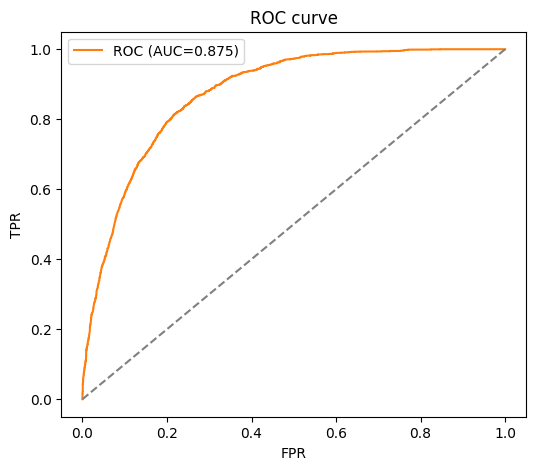

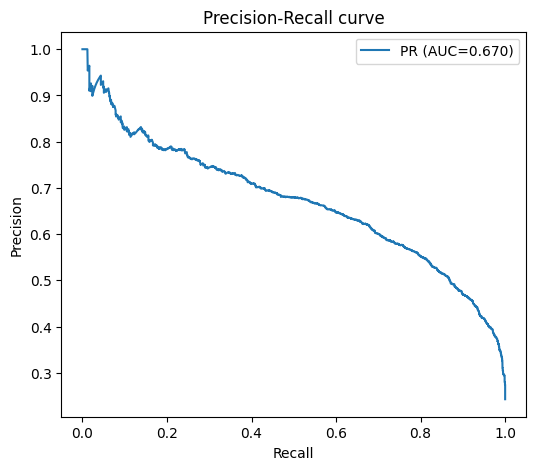

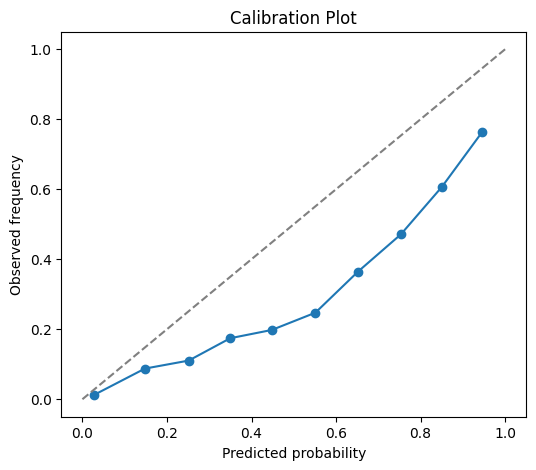

Threshold 0.5
 [[11449  3903]
 [  751  4176]]
              precision    recall  f1-score   support

           0       0.94      0.75      0.83     15352
           1       0.52      0.85      0.64      4927

    accuracy                           0.77     20279
   macro avg       0.73      0.80      0.74     20279
weighted avg       0.84      0.77      0.79     20279

Top-10% threshold: 0.8820021
Threshold 0.8820021152496338
 [[14840   512]
 [ 3411  1516]]
              precision    recall  f1-score   support

           0       0.81      0.97      0.88     15352
           1       0.75      0.31      0.44      4927

    accuracy                           0.81     20279
   macro avg       0.78      0.64      0.66     20279
weighted avg       0.80      0.81      0.77     20279

Saved validation map: validation_prob_map.html


ValueError: Input contains NaN

In [3]:
# validation_pipeline.py
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, brier_score_loss,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import GroupKFold, train_test_split, StratifiedKFold
import shap
import geopandas as gpd

# --------- CONFIG ----------
MASTER_PATH = r"C:\Users\gopal\Desktop\WILDSENTINEL\model\app\static\data\MASTER_TRAINING_DATA.csv"
MODEL_PATH  = r"C:\Users\gopal\Desktop\WILDSENTINEL\model\new_model\trained_model_xgb.joblib"
FEATURES = [
    "percent_forest", "percent_urban",
    "forest_change_rate", "urban_change_rate",
    "species_richness", "zoonotic_host_count",
    "total_import_events", "total_live_imports",
    "total_export_events", "total_live_exports"
]
TARGET_COL = "outbreak"   # change to actual column name used in training (0/1)

# --------- LOAD ----------
df = pd.read_csv(MASTER_PATH)
model = joblib.load(MODEL_PATH)

# Ensure target exists
if TARGET_COL not in df.columns:
    raise SystemExit(f"Target column '{TARGET_COL}' not found in master file.")

# Optionally filter by Year (useful if you want temporal split)
# df = df[df["Year"] <= 2023]

# Drop any rows missing features or target
df = df.dropna(subset=FEATURES + [TARGET_COL, "lat", "lon"])

X = df[FEATURES].values
y = df[TARGET_COL].values

# --------- SIMPLE HOLDOUT (stratified) ----------
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# Predict (model must support predict_proba)
probs = model.predict_proba(X_test)[:, 1]

# ---------- METRICS ----------
roc = roc_auc_score(y_test, probs)
precision, recall, _ = precision_recall_curve(y_test, probs)
prauc = auc(recall, precision)
brier = brier_score_loss(y_test, probs)

print("ROC AUC:", roc)
print("PR AUC:", prauc)
print("Brier:", brier)

# ---------- ROC / PR PLOT ----------
plt.figure(figsize=(6,5))
plt.plot(*zip(*[(0,0)]))  # placeholder
# ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f"ROC (AUC={roc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title("ROC curve")
plt.show()

# PR
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR (AUC={prauc:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve"); plt.legend(); plt.show()

# ---------- Calibration plot ----------
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label="Calibration")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency"); plt.title("Calibration Plot")
plt.show()

# ---------- Confusion at thresholds ----------
def print_cm_at_threshold(thresh=0.5):
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    print(f"Threshold {thresh}\n", cm)
    print(classification_report(y_test, preds))

print_cm_at_threshold(0.5)
# Policy threshold: top 10% most at-risk based on predicted probability
topk = np.percentile(probs, 90)
print("Top-10% threshold:", topk)
print_cm_at_threshold(topk)

# ---------- SPATIAL ERROR MAP ----------
import folium
test_df = df.loc[idx_test].copy()
test_df["prob"] = probs
test_df["residual"] = test_df["prob"] - test_df[TARGET_COL]

# Quick leaflet map: color by prob
m = folium.Map(location=[test_df.lat.mean(), test_df.lon.mean()], zoom_start=5, tiles='CartoDB positron')
from branca.colormap import linear
cm = linear.YlOrRd_09.scale(test_df["prob"].min(), test_df["prob"].max())
for _, r in test_df.iterrows():
    folium.CircleMarker(location=[r.lat, r.lon], radius=4,
                        color=cm(r["prob"]), fill=True, fill_opacity=0.8,
                        tooltip=f"p={r['prob']:.3f}, y={int(r[TARGET_COL])}").add_to(m)
cm.add_to(m)
m.save("validation_prob_map.html")
print("Saved validation map: validation_prob_map.html")

# ---------- SPATIAL CROSS-VAL (GroupKFold by country or spatial bins) ----------
# Group by Country (if countries in data)
if "Country" in df.columns:
    groups = df["Country"].values
    gkf = GroupKFold(n_splits=5)
    rocs = []
    for train_idx, test_idx in gkf.split(X, y, groups):
        p = model.predict_proba(X[test_idx])[:,1]
        rocs.append(roc_auc_score(y[test_idx], p))
    print("GroupKFold ROC AUC per fold:", rocs, "mean:", np.mean(rocs))

# ---------- SHAP explanation ----------
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, pd.DataFrame(X_test, columns=FEATURES), show=True)



================ CONFUSION MATRIX (threshold=0.5) ================
[[11449  3903]
 [  751  4176]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9384    0.7458    0.8311     15352
           1     0.5169    0.8476    0.6422      4927

    accuracy                         0.7705     20279
   macro avg     0.7277    0.7967    0.7366     20279
weighted avg     0.8360    0.7705    0.7852     20279



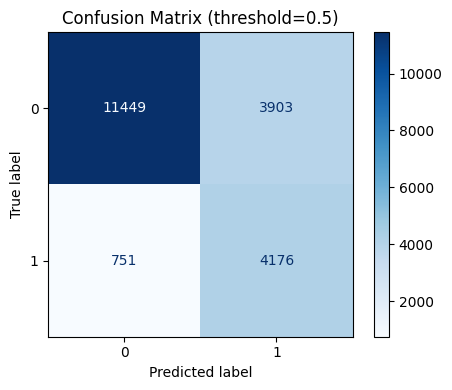

Saved confusion matrix image as cm_05.png

================ CONFUSION MATRIX (threshold=0.4928162693977356) ================
[[11420  3932]
 [  746  4181]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9387    0.7439    0.8300     15352
           1     0.5153    0.8486    0.6413      4927

    accuracy                         0.7693     20279
   macro avg     0.7270    0.7962    0.7356     20279
weighted avg     0.8358    0.7693    0.7841     20279



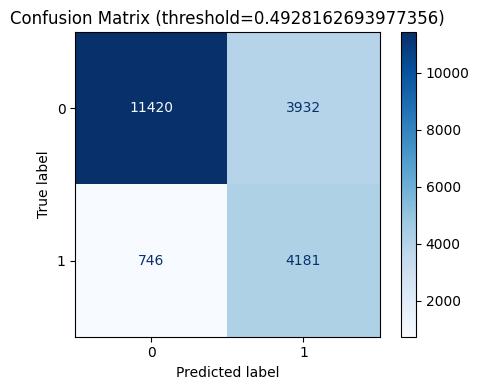

Saved confusion matrix image as cm_top10.png


: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def show_confusion_matrix(y_true, y_scores, threshold=0.5, name="cm_default"):
    # Convert probability to class
    y_pred = (y_scores >= threshold).astype(int)

    # Compute matrix
    cm = confusion_matrix(y_true, y_pred)

    # PRINT results
    print(f"\n================ CONFUSION MATRIX (threshold={threshold}) ================")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # DISPLAY matrix as plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    ax.set_title(f"Confusion Matrix (threshold={threshold})")

    # Ensure plot renders
    plt.tight_layout()
    plt.show()

    # Save image in case GUI fails
    fig.savefig(f"{name}.png")
    print(f"Saved confusion matrix image as {name}.png")

# -------- RUN CONFUSION MATRICES --------

# 1) Default threshold 0.5
show_confusion_matrix(y_test, probs, threshold=0.5, name="cm_05")

# 2) Policy threshold (top 10%)
topk = np.percentile(probs, 60)
show_confusion_matrix(y_test, probs, threshold=topk, name="cm_top10")
